# Production Statistics Demo

## Overview

This demo simulates how operational production statistics can be created by combining structured exports from multiple systems into a relational model using Python, SQLite3, SQL, and Pandas.

The purpose is to demonstrate:
- relational data modeling
- structured operational analytics
- automated reporting
- aggregation of production statistics
- transformation of fragmented operational data into machine-readable matrices and reports

The demo is inspired by real operational workflows used in Point of Care laboratory environments where:
- instruments are distributed across multiple wards or units
- users require access rights to specific instrument classes
- production data must be aggregated and analyzed
- reporting and billing statistics are generated from multiple systems

The demo uses simplified synthetic data.

---

# Simplified Relational Model

The demo uses four CSV input files:

```text
users.csv
access_rules.csv
instruments.csv
production_results.csv
```

The files are loaded into an in-memory SQLite3 database and combined using SQL joins.

The relational structure is based on:
- users employed at units
- access rights between units
- instruments located at units
- production results generated by instruments

---

# Simplification Compared to Real Production Systems

This demo intentionally simplifies several real-world integration problems.

The `unit_id` values are already normalized and identical between systems. In real operational environments this is rarely the case.

When combining exports from:
- LIS systems
- Point of Care systems
- HR systems
- billing systems
- production systems

translation tables and key normalization are often required because different systems may use different identifiers for the same ward, customer, instrument group, or organizational structure.

The demo focuses on the relational logic and operational aggregation rather than on the translation layer itself.

---

# Calculations and Aggregations

## Monthly Production Statistics

Monthly production statistics are generated per:
- month
- unit
- instrument class

The calculations include:
- number of runs
- total production
- average results per run
- users with access
- results per user with access

Output file:

```text
monthly_unit_class_stats.csv
```

---

## Instrument Inventory Summary

The instrument inventory is aggregated by:
- unit
- instrument class

This creates a summary of how many instruments of each class are located at each unit.

Output file:

```text
instrument_summary_by_unit_class.csv
```

---

## Instrument Matrix

A matrix representation is created where:
- rows represent units
- columns represent instrument classes
- values represent the number of instruments

Output file:

```text
instrument_matrix_by_unit_class.csv
```

---

## Monthly Production Matrices

Monthly production matrices are generated dynamically for each month.

The matrices contain:
- rows = units
- columns = instrument classes
- values = total production

Example output files:

```text
production_matrix_2026-01.csv
production_matrix_2026-02.csv
production_matrix_2026-03.csv
```

---

## Unit Summary Statistics

Production is aggregated at unit level.

The calculations include:
- total production
- number of runs
- users with access
- results per user with access

Output file:

```text
unit_summary.csv
```

---

## Monthly Summary Statistics

Production is aggregated at monthly level.

The calculations include:
- total production
- total number of runs

Output file:

```text
month_summary.csv
```

---

## Instrument Class Summary

Production is aggregated by instrument class.

The calculations include:
- total production
- number of runs

Output file:

```text
class_summary.csv
```

---

# Generated Charts

## Production per Unit

```text
chart_total_production_per_unit.png
```

Bar chart showing total production volume per unit.

---

## Production per Month

```text
chart_total_production_per_month.png
```

Line chart showing total monthly production.

---

## Production per Instrument Class

```text
chart_total_production_by_class.png
```

Bar chart showing production volume grouped by instrument class.

---

## Results per User with Access

```text
chart_results_per_user_with_access.png
```

Bar chart showing operational production load relative to the number of users with access.

---

## Production per Unit and Instrument Class

```text
chart_total_production_per_unit_and_class.png
```

Grouped bar chart showing:
- units
- instrument classes
- total production

---

## Monthly Production per Unit and Instrument Class

```text
chart_monthly_production_by_class_A1.png
chart_monthly_production_by_class_A2.png
...
```

Monthly grouped bar charts generated separately for each unit.

---

## Instrument Distribution Heatmap

```text
heatmap_instrument_distribution.png
```

Heatmap visualization of:
- units
- instrument classes
- number of instruments

---

## Employees per Unit

```text
bar_employees_per_unit.png
```

Bar chart showing the number of employees assigned to each unit.

---

# Key Concept

The main purpose of the demo is to show how:
- structured relational modeling
- shared keys
- SQL joins
- matrix representations
- aggregation logic

can transform fragmented operational information into reproducible production statistics and automated reports.

The complexity does not primarily originate from the code itself, but from the operational relationships between:
- users
- units
- instruments
- instrument classes
- production systems
- access rights
- reporting structures

# Code

The original build integrated MS Access, MS Excel, and MS PowerPoint. The same concept is maintained in this demo, but rewritten using Python, SQLite3, Pandas, and Matplotlib.

The goal is not to create a web UI or a live dashboard connected to a database. Instead, the demo uses an in-memory SQLite database to perform the relational calculations, then exports result files and chart images separately.

This keeps the workflow simple, reproducible, and easy to inspect:

```text
CSV input files
→ SQLite3 in-memory database
→ SQL joins and aggregations
→ CSV result files
→ PNG chart files
```

The notebook can therefore be run as a self-contained reporting pipeline without requiring a persistent database server or web application.

   production_month unit_id instrument_class  users_with_access  \
0           2026-01      A1            ALPHA                100   
1           2026-01      A1             BETA                100   
2           2026-01      A1            DELTA                100   
3           2026-01      A1            GAMMA                100   
4           2026-01      A2            ALPHA                 75   
..              ...     ...              ...                ...   
71          2026-04      A4            GAMMA                 46   
72          2026-04      A5            ALPHA                 27   
73          2026-04      A5             BETA                 27   
74          2026-04      A5            DELTA                 27   
75          2026-04      A5            GAMMA                 27   

    number_of_runs  total_results  avg_results_per_run  \
0              232          30343               130.79   
1              263          20936                79.60   
2               89   

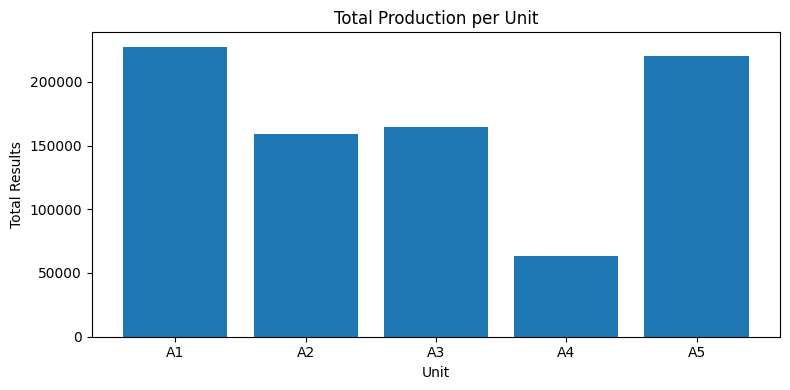

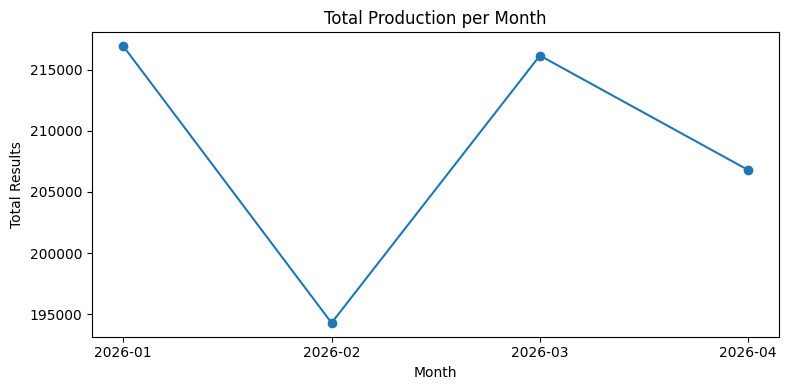

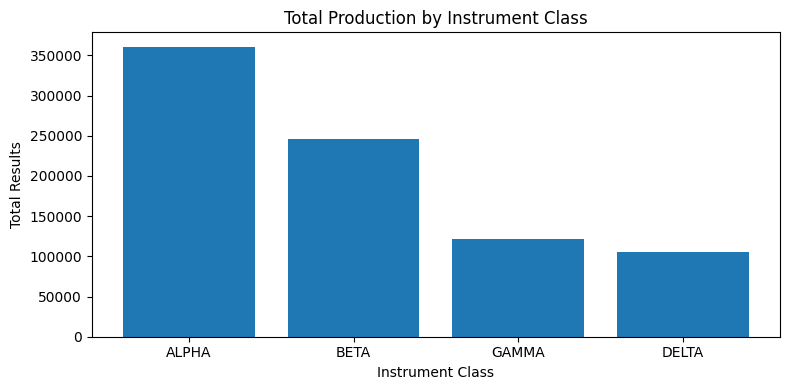

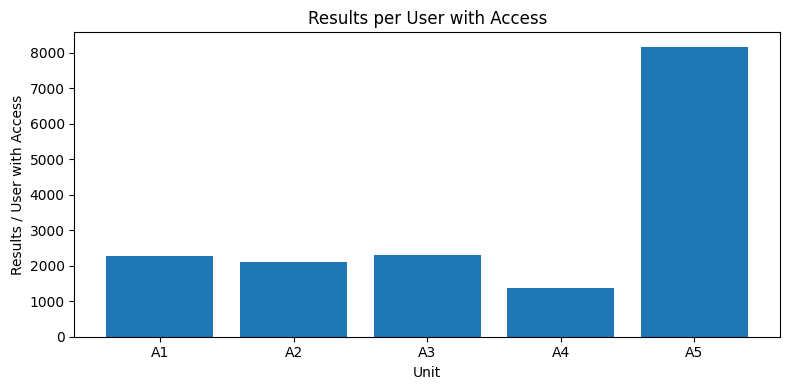

instrument_class     ALPHA     BETA    DELTA    GAMMA
unit_id                                              
A1                115932.0  79670.0  12185.0  19630.0
A2                 57015.0  34730.0  31199.0  35842.0
A3                 72451.0  53109.0  27166.0  11579.0
A4                 43612.0      0.0   7443.0  12110.0
A5                 71701.0  78743.0  27861.0  42212.0


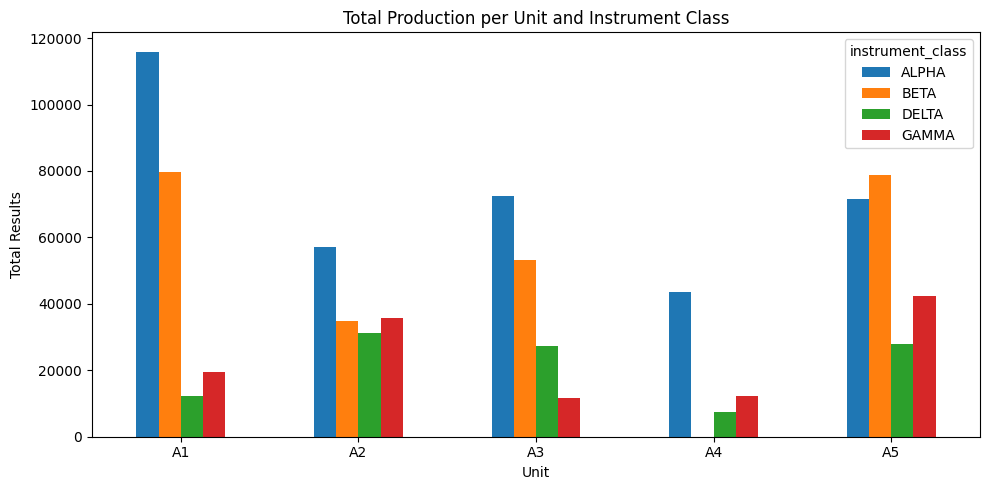


===== A1 =====
instrument_class  ALPHA   BETA  DELTA  GAMMA
production_month                            
2026-01           30343  20936   3322   4576
2026-02           27258  18843   2682   4983
2026-03           28997  20874   3351   5097
2026-04           29334  19017   2830   4974


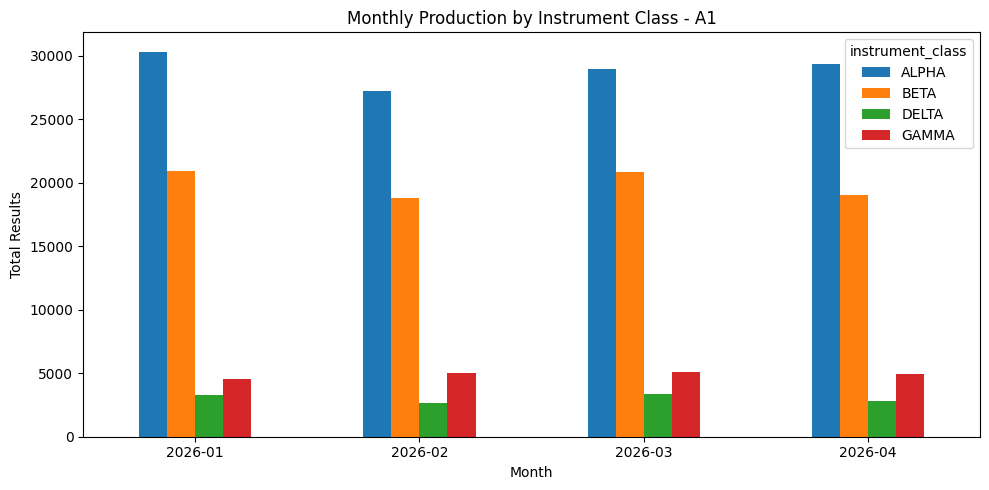


===== A2 =====
instrument_class  ALPHA  BETA  DELTA  GAMMA
production_month                           
2026-01           14551  9185   8400   9265
2026-02           12902  7361   7330   8199
2026-03           14519  9552   8073   9037
2026-04           15043  8632   7396   9341


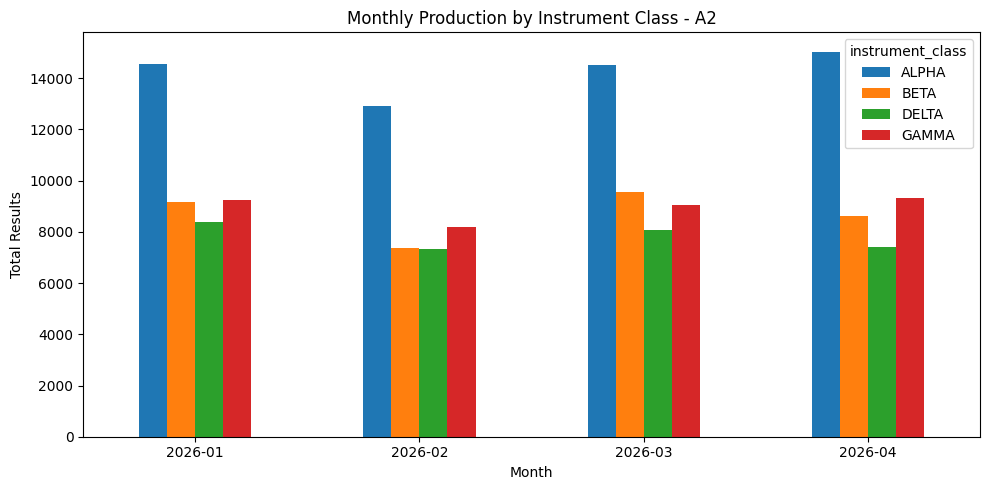


===== A3 =====
instrument_class  ALPHA   BETA  DELTA  GAMMA
production_month                            
2026-01           19363  13694   6978   3220
2026-02           17096  12182   6321   2664
2026-03           18632  14009   7157   2952
2026-04           17360  13224   6710   2743


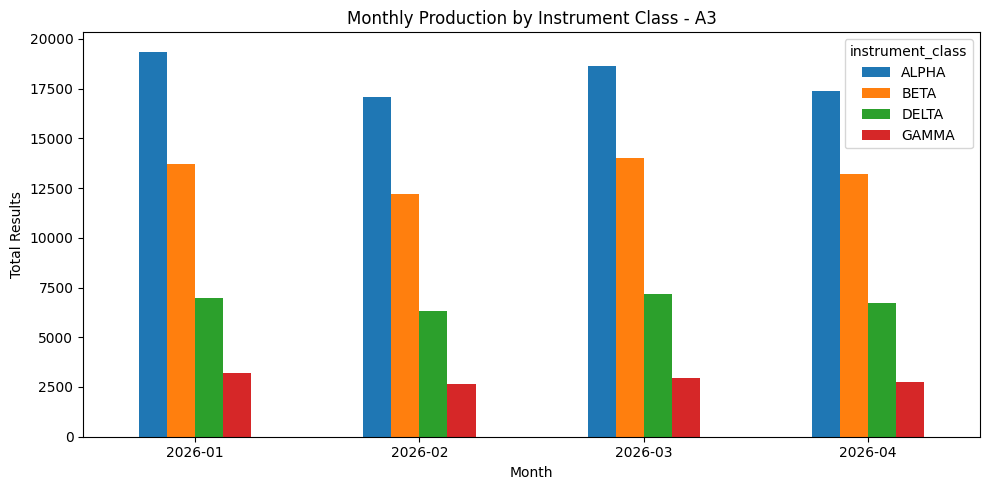


===== A4 =====
instrument_class  ALPHA  DELTA  GAMMA
production_month                     
2026-01           10883   1969   3219
2026-02           10425   1654   2552
2026-03           10949   1972   3130
2026-04           11355   1848   3209


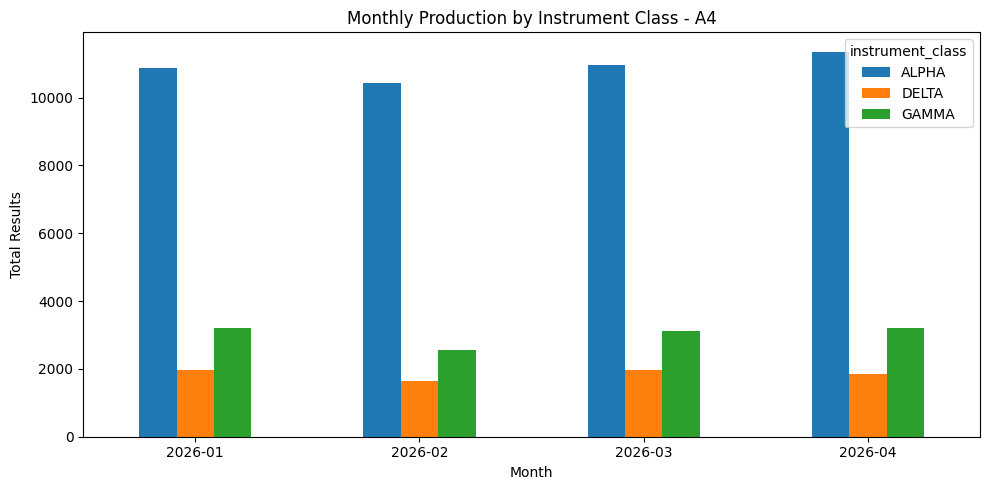


===== A5 =====
instrument_class  ALPHA   BETA  DELTA  GAMMA
production_month                            
2026-01           18239  20752   6852  11193
2026-02           16243  18839   6840   9907
2026-03           19216  20427   7417  10810
2026-04           18003  18725   6752  10302


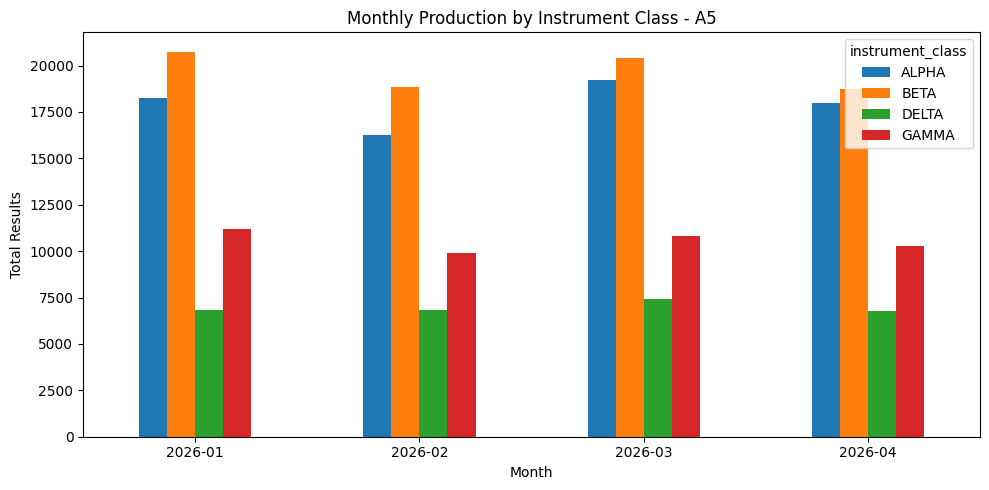

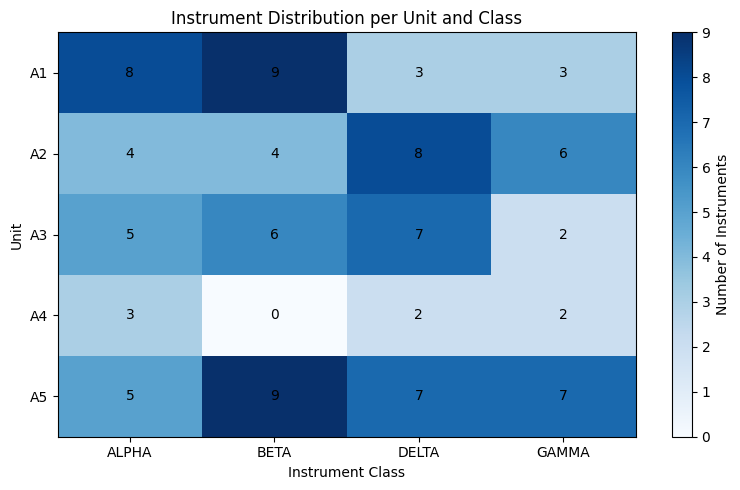

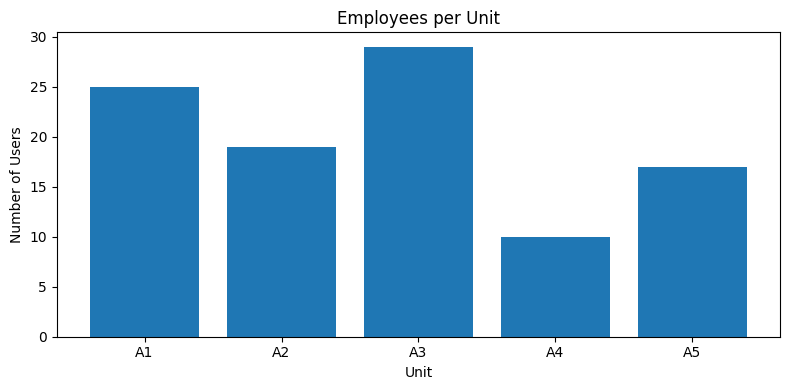

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load CSV files into SQLite
# --------------------------------------------------

conn = sqlite3.connect(":memory:")

pd.read_csv("users.csv").to_sql("users", conn, index=False, if_exists="replace")
pd.read_csv("access_rules.csv").to_sql("access_rules", conn, index=False, if_exists="replace")
pd.read_csv("instruments.csv").to_sql("instruments", conn, index=False, if_exists="replace")
pd.read_csv("production_results.csv").to_sql("production_results", conn, index=False, if_exists="replace")


# --------------------------------------------------
# Monthly production statistics
# --------------------------------------------------

query_monthly_unit_class_stats = """
WITH production AS (
    SELECT
        substr(pr.run_date, 1, 7) AS production_month,
        i.unit_id,
        i.instrument_class,
        COUNT(pr.result_id) AS number_of_runs,
        SUM(pr.result_count) AS total_results,
        AVG(pr.result_count) AS avg_results_per_run
    FROM production_results pr
    JOIN instruments i
        ON i.instrument_id = pr.instrument_id
    GROUP BY
        production_month,
        i.unit_id,
        i.instrument_class
),

access_counts AS (
    SELECT
        ar.access_unit AS unit_id,
        COUNT(DISTINCT u.user_id) AS users_with_access
    FROM access_rules ar
    JOIN users u
        ON u.employed_at = ar.employed_at
    GROUP BY
        ar.access_unit
)

SELECT
    p.production_month,
    p.unit_id,
    p.instrument_class,
    ac.users_with_access,
    p.number_of_runs,
    p.total_results,
    ROUND(p.avg_results_per_run, 2) AS avg_results_per_run,
    ROUND(
        CAST(p.total_results AS REAL) / ac.users_with_access,
        2
    ) AS results_per_user_with_access
FROM production p
LEFT JOIN access_counts ac
    ON ac.unit_id = p.unit_id
ORDER BY
    p.production_month,
    p.unit_id,
    p.instrument_class
"""

monthly_stats = pd.read_sql_query(query_monthly_unit_class_stats, conn)

monthly_stats.to_csv("monthly_unit_class_stats.csv", index=False)

print(monthly_stats)


# --------------------------------------------------
# Instrument summary by unit and class
# --------------------------------------------------

instruments_df = pd.read_csv("instruments.csv")

instrument_summary = (
    instruments_df
    .groupby(["unit_id", "instrument_class"])
    .agg(number_of_instruments=("instrument_id", "count"))
    .reset_index()
    .sort_values(["unit_id", "instrument_class"])
)

instrument_summary.to_csv(
    "instrument_summary_by_unit_class.csv",
    index=False
)

print(instrument_summary)

# --------------------------------------------------
# Monthly production matrices
# --------------------------------------------------

query_monthly_matrix = """
SELECT
    substr(pr.run_date, 1, 7) AS production_month,
    i.unit_id,
    i.instrument_class,
    SUM(pr.result_count) AS total_results
FROM production_results pr
JOIN instruments i
    ON i.instrument_id = pr.instrument_id
GROUP BY
    production_month,
    i.unit_id,
    i.instrument_class
ORDER BY
    production_month,
    i.unit_id,
    i.instrument_class
"""

monthly_df = pd.read_sql_query(query_monthly_matrix, conn)

months = monthly_df["production_month"].unique()

production_matrices = {}

for month in months:
    month_df = monthly_df[monthly_df["production_month"] == month]

    matrix = month_df.pivot_table(
        index="unit_id",
        columns="instrument_class",
        values="total_results",
        aggfunc="sum",
        fill_value=0
    )

    production_matrices[month] = matrix

    matrix.to_csv(f"production_matrix_{month}.csv")

    print(f"\n===== {month} =====")
    print(matrix)



# --------------------------------------------------
# Dashboard summary: total production per unit
# --------------------------------------------------

unit_summary = (
    monthly_stats
    .groupby("unit_id", as_index=False)
    .agg(
        total_results=("total_results", "sum"),
        users_with_access=("users_with_access", "max"),
        number_of_runs=("number_of_runs", "sum")
    )
)

unit_summary["results_per_user_with_access"] = (
    unit_summary["total_results"] / unit_summary["users_with_access"]
).round(2)

unit_summary.to_csv("unit_summary.csv", index=False)

print(unit_summary)


# --------------------------------------------------
# Dashboard summary: total production per month
# --------------------------------------------------

month_summary = (
    monthly_stats
    .groupby("production_month", as_index=False)
    .agg(
        total_results=("total_results", "sum"),
        number_of_runs=("number_of_runs", "sum")
    )
)

month_summary.to_csv("month_summary.csv", index=False)

print(month_summary)


# --------------------------------------------------
# Dashboard summary: production by instrument class
# --------------------------------------------------

class_summary = (
    monthly_stats
    .groupby("instrument_class", as_index=False)
    .agg(
        total_results=("total_results", "sum"),
        number_of_runs=("number_of_runs", "sum")
    )
    .sort_values("total_results", ascending=False)
)

class_summary.to_csv("class_summary.csv", index=False)

print(class_summary)


# --------------------------------------------------
# Chart: total production per unit
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(unit_summary["unit_id"], unit_summary["total_results"])
plt.title("Total Production per Unit")
plt.xlabel("Unit")
plt.ylabel("Total Results")
plt.tight_layout()
plt.savefig("chart_total_production_per_unit.png", dpi=150)
plt.show()

# --------------------------------------------------
# Chart: total production per month
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.plot(month_summary["production_month"], month_summary["total_results"], marker="o")
plt.title("Total Production per Month")
plt.xlabel("Month")
plt.ylabel("Total Results")
plt.tight_layout()
plt.savefig("chart_total_production_per_month.png", dpi=150)
plt.show()

# --------------------------------------------------
# Chart: production by instrument class
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(class_summary["instrument_class"], class_summary["total_results"])
plt.title("Total Production by Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Total Results")
plt.tight_layout()
plt.savefig("chart_total_production_by_class.png", dpi=150)
plt.show()

# --------------------------------------------------
# Chart: results per user with access
# --------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(unit_summary["unit_id"], unit_summary["results_per_user_with_access"])
plt.title("Results per User with Access")
plt.xlabel("Unit")
plt.ylabel("Results / User with Access")
plt.tight_layout()
plt.savefig("chart_results_per_user_with_access.png", dpi=150)
plt.show()



# --------------------------------------------------
# Chart: total production per unit and instrument class
# --------------------------------------------------

production_by_unit_class = (
    monthly_stats
    .groupby(
        ["unit_id", "instrument_class"],
        as_index=False
    )
    .agg(
        total_results=("total_results", "sum")
    )
)

# pivot for grouped bar chart

plot_df = production_by_unit_class.pivot(
    index="unit_id",
    columns="instrument_class",
    values="total_results"
).fillna(0)

print(plot_df)

# create chart

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Total Production per Unit and Instrument Class")
plt.xlabel("Unit")
plt.ylabel("Total Results")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "chart_total_production_per_unit_and_class.png",
    dpi=150
)

plt.show()


# --------------------------------------------------
# Chart: monthly production per unit and instrument class
# One subplot per unit
# --------------------------------------------------

monthly_unit_class = (
    monthly_stats
    .groupby(
        ["production_month", "unit_id", "instrument_class"],
        as_index=False
    )
    .agg(
        total_results=("total_results", "sum")
    )
)

units = sorted(monthly_unit_class["unit_id"].unique())

for unit in units:

    unit_df = monthly_unit_class[
        monthly_unit_class["unit_id"] == unit
    ]

    plot_df = unit_df.pivot(
        index="production_month",
        columns="instrument_class",
        values="total_results"
    ).fillna(0)

    print(f"\n===== {unit} =====")
    print(plot_df)

    plot_df.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title(f"Monthly Production by Instrument Class - {unit}")
    plt.xlabel("Month")
    plt.ylabel("Total Results")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.savefig(
        f"chart_monthly_production_by_class_{unit}.png",
        dpi=150
    )

    plt.show()
    

# --------------------------------------------------
# Instrument matrix
# --------------------------------------------------

instrument_matrix = instruments_df.pivot_table(
    index="unit_id",
    columns="instrument_class",
    values="instrument_id",
    aggfunc="count",
    fill_value=0
)

instrument_matrix.to_csv("instrument_matrix_by_unit_class.csv")

# --------------------------------------------------
# Employees per unit
# --------------------------------------------------

users_df = pd.read_csv("users.csv")

employee_summary = (
    users_df
    .groupby("employed_at")
    .agg(number_of_users=("user_id", "count"))
    .reset_index()
    .rename(columns={"employed_at": "unit_id"})
    .sort_values("unit_id")
)

employee_summary.to_csv("employee_summary_by_unit.csv", index=False)

# --------------------------------------------------
# Plot 1: heatmap instruments
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.imshow(
    instrument_matrix,
    aspect="auto",
    cmap="Blues"
)

plt.colorbar(label="Number of Instruments")

plt.xticks(
    range(len(instrument_matrix.columns)),
    instrument_matrix.columns
)

plt.yticks(
    range(len(instrument_matrix.index)),
    instrument_matrix.index
)

plt.title("Instrument Distribution per Unit and Class")
plt.xlabel("Instrument Class")
plt.ylabel("Unit")

for i in range(instrument_matrix.shape[0]):
    for j in range(instrument_matrix.shape[1]):
        value = instrument_matrix.iloc[i, j]
        plt.text(j, i, str(value), ha="center", va="center")

plt.tight_layout()
plt.savefig("heatmap_instrument_distribution.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 2: bar chart employees
# --------------------------------------------------

plt.figure(figsize=(8, 4))

plt.bar(
    employee_summary["unit_id"],
    employee_summary["number_of_users"]
)

plt.title("Employees per Unit")
plt.xlabel("Unit")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.savefig("bar_employees_per_unit.png", dpi=150)
plt.show()